In [16]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [7]:
df = pd.read_csv('house_price_dataset.csv')

In [ ]:
#df.head()
# df.shape
#df.info()
df.describe()


,Area,Bedrooms,Bathrooms,Age,Parking,Price
count,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,2055.000000,3.700000,3.100000,4.300000,1.950000,585500.000000
std,732.317877,1.128576,1.372665,3.555574,0.759155,204256.675469
min,900.000000,2.000000,1.000000,1.000000,1.000000,280000.000000
25%,1475.000000,3.000000,2.000000,1.750000,1.000000,415000.000000
50%,2050.000000,4.000000,3.000000,3.000000,2.000000,590000.000000
75%,2625.000000,5.000000,4.000000,6.250000,2.250000,745000.000000
max,3200.000000,5.000000,5.000000,12.000000,3.000000,900000.000000


In [21]:
print(df.isnull().sum())

Area         0
Bedrooms     0
Bathrooms    0
Age          0
Parking      0
Price        0
dtype: int64


In [22]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


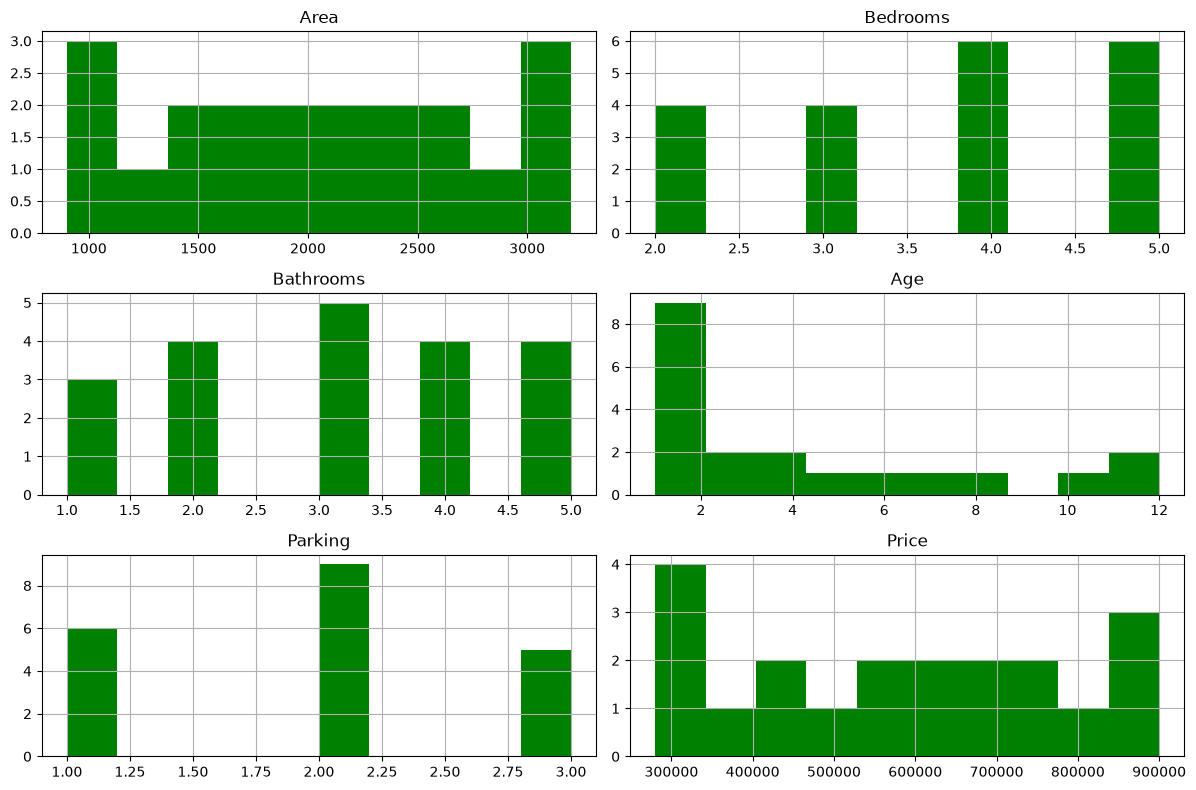

In [25]:
df.hist(figsize=(12,8),color='g')
plt.tight_layout()
plt.show()

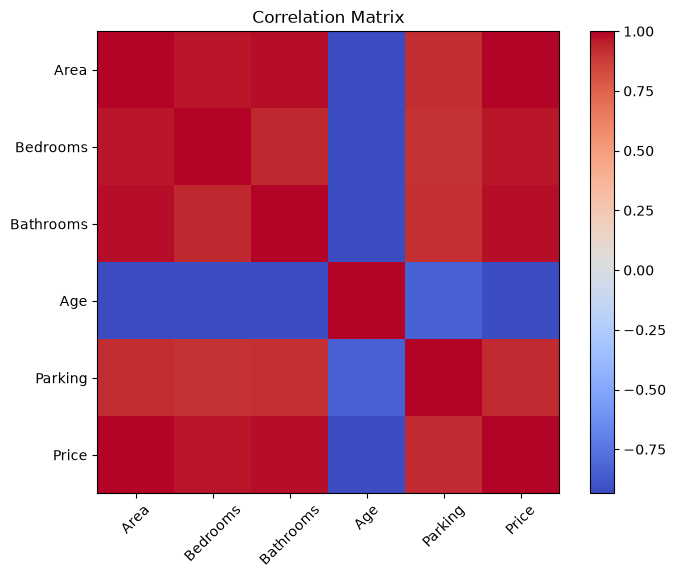

In [26]:
corr = df.corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.show()

In [28]:
print(corr)

               Area  Bedrooms  Bathrooms       Age   Parking     Price
Area       1.000000  0.963507   0.983805 -0.928397  0.923515  0.999266
Bedrooms   0.963507  1.000000   0.937691 -0.933869  0.903031  0.964185
Bathrooms  0.983805  0.937691   1.000000 -0.923094  0.914176  0.983453
Age       -0.928397 -0.933869  -0.923094  1.000000 -0.832596 -0.920591
Parking    0.923515  0.903031   0.914176 -0.832596  1.000000  0.928489
Price      0.999266  0.964185   0.983453 -0.920591  0.928489  1.000000


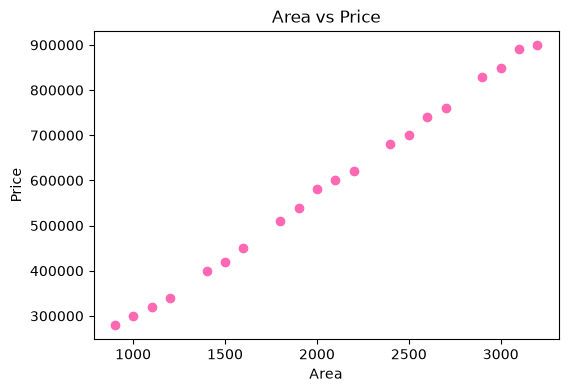

In [30]:
plt.figure(figsize=(6,4))

plt.scatter(df["Area"], df["Price"],c='hotpink')

plt.xlabel("Area")

plt.ylabel("Price")

plt.title("Area vs Price")

plt.show()

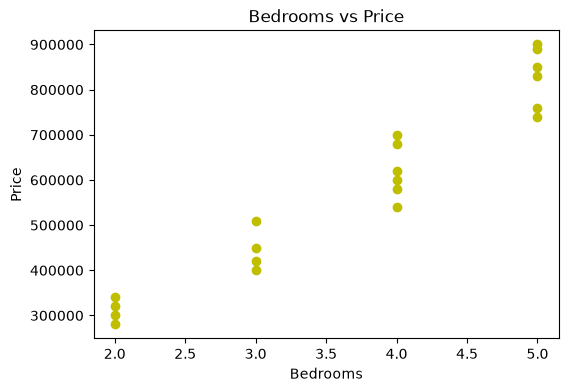

In [32]:
plt.figure(figsize=(6,4))

plt.scatter(df["Bedrooms"], df["Price"],c='y')

plt.xlabel("Bedrooms")

plt.ylabel("Price")

plt.title("Bedrooms vs Price")

plt.show()

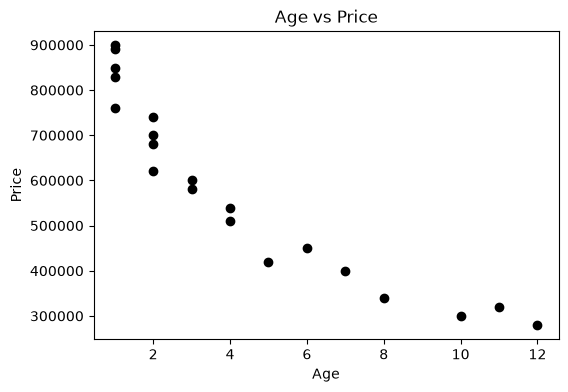

In [35]:
plt.figure(figsize=(6,4))

plt.scatter(df["Age"], df["Price"],c ='k')

plt.xlabel("Age")

plt.ylabel("Price")

plt.title("Age vs Price")

plt.show()

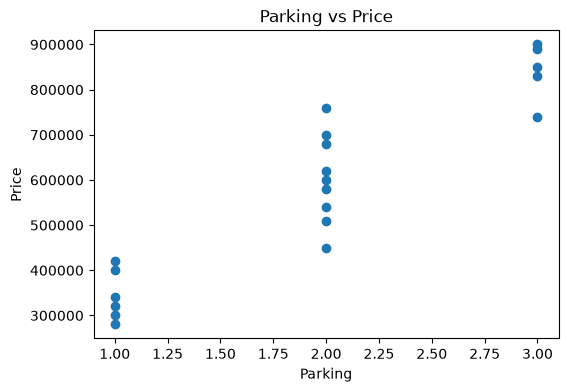

In [36]:
plt.figure(figsize=(6,4))

plt.scatter(df["Parking"], df["Price"])

plt.xlabel("Parking")

plt.ylabel("Price")

plt.title("Parking vs Price")

plt.show()

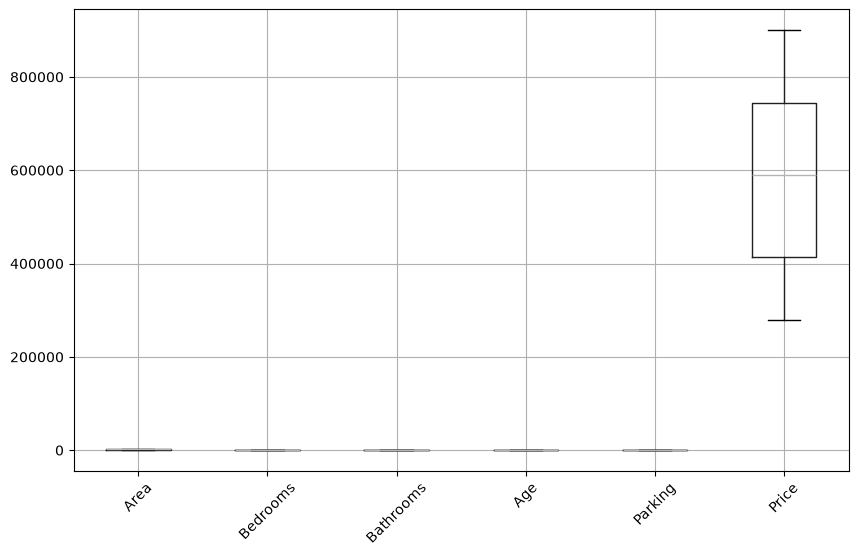

In [37]:
plt.figure(figsize=(10,6))

df.boxplot()

plt.xticks(rotation=45)

plt.show()

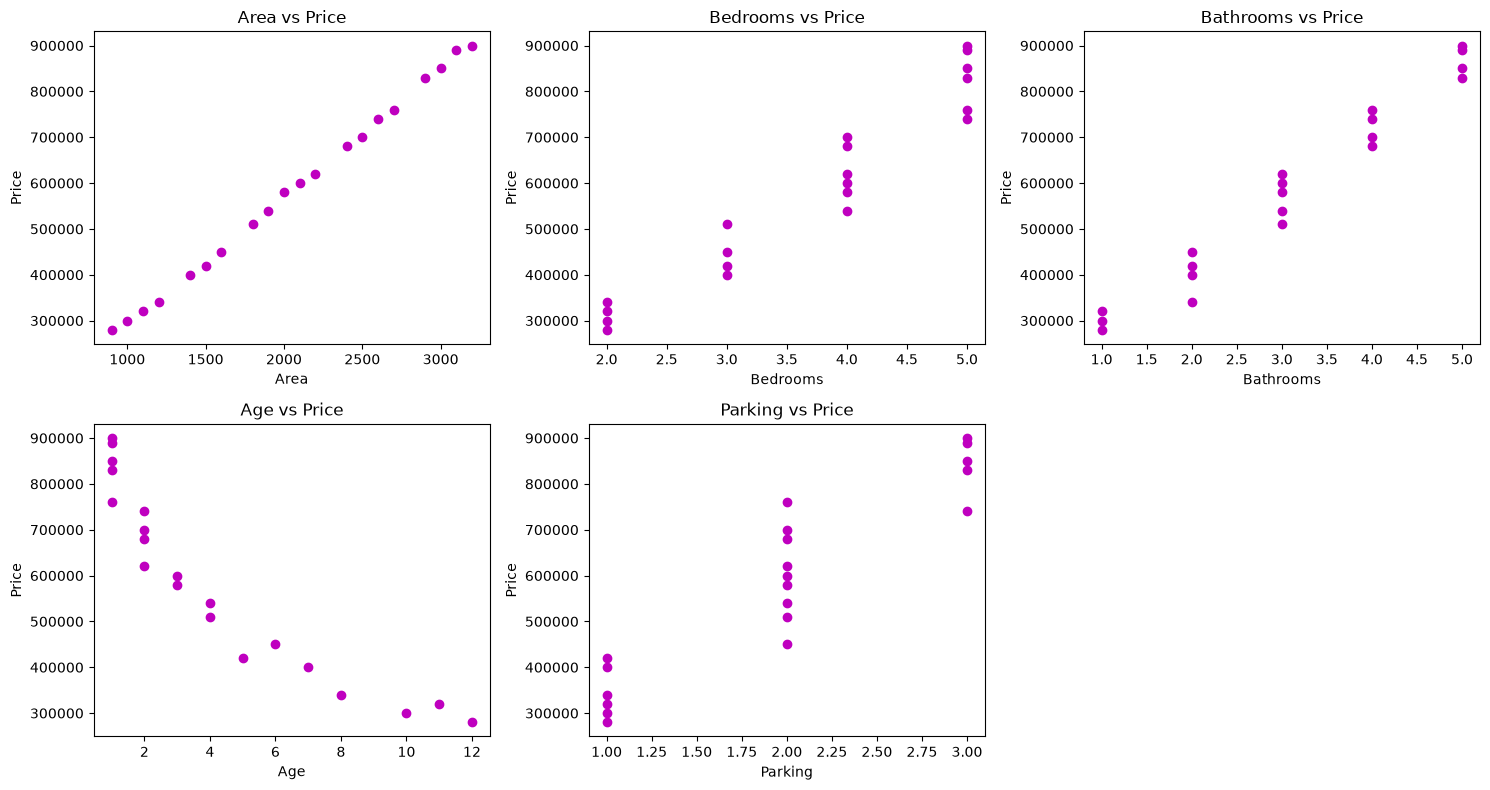

In [40]:
features = ["Area", "Bedrooms", "Bathrooms", "Age", "Parking"]

plt.figure(figsize=(15,8))

for i, feature in enumerate(features):
    plt.subplot(2,3,i+1)
    plt.scatter(df[feature], df["Price"],c='m')
    plt.xlabel(feature)
    plt.ylabel("Price")
    plt.title(f"{feature} vs Price")

plt.tight_layout()
plt.show()

In [41]:
x = df[['Area','Bedrooms','Bathrooms','Age','Parking']]
y= df['Price']

In [42]:
x.head()


,Area,Bedrooms,Bathrooms,Age,Parking
0,1000,2,1,10,1
1,1200,2,2,8,1
2,1500,3,2,5,1
3,1800,3,3,4,2
4,2000,4,3,3,2


In [44]:
print(y.head())

0    300000
1    340000
2    420000
3    510000
4    580000
Name: Price, dtype: int64


In [45]:
x_train,x_test,y_train,y_test = train_test_split(
    x,y,
    random_state=42,
    test_size=0.2
)

In [48]:
print("X_train :", x_train.shape)
print("X_test  :", x_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (16, 5)
X_test  : (4, 5)
y_train : (16,)
y_test  : (4,)


In [51]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 253.6 ,12192.29,11081.78, 4086.05, 6038.85]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Area','Bedrooms','Bathrooms','Age','Parking']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-4.461e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [52]:
coef = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": model.coef_
})

print(coef)

     Feature   Coefficient
0       Area    253.601208
1   Bedrooms  12192.289471
2  Bathrooms  11081.783726
3        Age   4086.047613
4    Parking   6038.848750


In [53]:
print(model.intercept_)

-44612.99301196274


In [56]:
y_pred = model.predict(x_test)

print(y_pred)

[291353.90264124 746327.37178728 594299.89340282 344983.83276087]


In [57]:
result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(result)

    Actual      Predicted
0   300000  291353.902641
17  740000  746327.371787
15  600000  594299.893403
1   340000  344983.832761


In [59]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score


In [60]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score :", r2)

MAE : 6414.352126021549
MSE : 43030109.369778074
RMSE: 6559.73394047183
R² Score : 0.9987068336778429


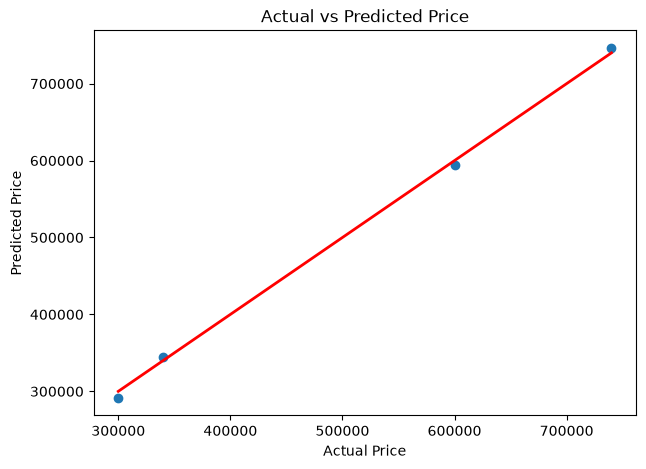

In [61]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")

plt.show()

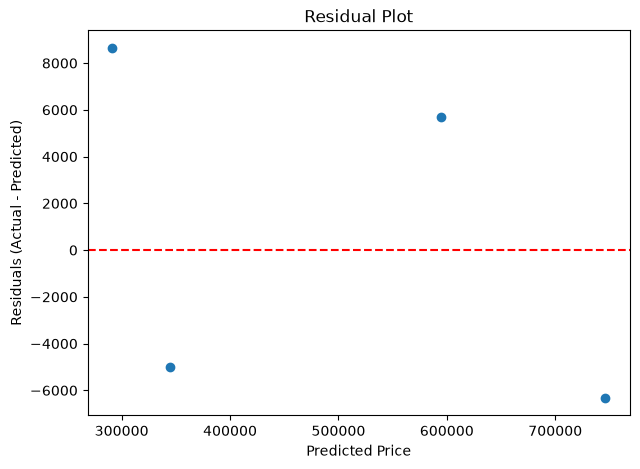

In [63]:
residuals = y_test - y_pred
plt.figure(figsize=(7,5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")

plt.show()

In [64]:
new_house = [[2300, 4, 3, 2, 2]]

predicted_price = model.predict(new_house)

print("Predicted House Price:", predicted_price[0])

Predicted House Price: 640934.0874096884


c:\Users\lucky\Documents\leniear_regression\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [67]:
new_house = [[1100,3,2,0,1]]

In [68]:
predicted_price = model.predict(new_house)

print("new home: ",predicted_price)

new home:  [299127.62051404]


c:\Users\lucky\Documents\leniear_regression\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [5]:
import joblib

In [ ]:
joblib.dump(model,"house_price_model.pkl")

In [6]:
loaded_model = joblib.load("house_price_model.pkl")

In [8]:
area = int(input("Enter area_sqft of house : "))
bedroom = int(input("enter bedrooms : "))
bathroom = int(input("enter bathrooms : "))
Age1 = int(input("enter age : "))
parking1 = int(input("enter parking : "))


prediction = loaded_model.predict([[area, bedroom, bathroom, Age1, parking1]])
print("area:",area)
print("bedrooms:",bedroom)
print("Bathrooms :",bathroom)
print("age of house :",Age1)
print("parking are:",parking1)

print("New house price :",prediction)

area: 1500
bedrooms: 1
Bathrooms : 1
age of house : 1
parking are: 2
New house price : [375226.63745114]


c:\Users\lucky\Documents\leniear_regression\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
